# 01: Pulse Broadening Under Group Velocity Dispersion

**Summary**: We study how optical pulses broaden as they propagate through a dispersive fiber.
Group velocity dispersion (GVD) causes different frequency components of the pulse to travel at
different speeds, leading to temporal broadening. We validate our numerical solver against the
exact analytical formula for Gaussian pulse broadening and explore the role of the dispersion
sign (anomalous vs. normal) and pulse shape (Gaussian vs. sech).

**Key results**:
- Gaussian pulse broadening matches $T(\xi) = T_0\sqrt{1 + \xi^2}$ to < 2% error
- Anomalous and normal dispersion produce opposite chirps but identical broadening rates
- The sech pulse broadens differently from the Gaussian — no simple analytical formula

**Physics context**: GVD is the dominant linear effect in silica fibers. Understanding it is
essential for fiber-optic communication system design, where dispersion limits the bit rate,
and for ultrafast optics, where dispersion must be compensated to maintain short pulse durations.

## Theory: Group Velocity Dispersion

### The Normalized NLSE (Dispersion Only)

When we set the nonlinear parameter $N^2 = 0$, the NLSE reduces to the linear dispersive equation:

$$i\frac{\partial u}{\partial \xi} + \frac{s}{2}\frac{\partial^2 u}{\partial \tau^2} = 0$$

where:
- $u(\xi, \tau)$ is the normalized pulse envelope
- $\xi = z / L_D$ is the propagation distance in units of the dispersion length
- $\tau = t / T_0$ is the retarded time in units of the pulse width
- $s = -\text{sign}(\beta_2)$ is the dispersion sign parameter

### The Dispersion Length

$$L_D = \frac{T_0^2}{|\beta_2|}$$

This is the distance over which a pulse broadens by a factor of $\sqrt{2}$. For a typical
telecom fiber ($\beta_2 = -20$ ps²/km, $T_0 = 10$ ps): $L_D = 5$ km.

### Analytical Solution for a Gaussian Pulse

For an unchirped Gaussian input $u(0, \tau) = \exp(-\tau^2/2)$, the exact solution gives
a pulse width that evolves as:

$$T(\xi) = T_0 \sqrt{1 + \xi^2}$$

This is our validation target — the numerical solver must reproduce this formula.

### Physical Mechanism: Frequency-Dependent Group Velocity

Dispersion arises because the refractive index $n(\omega)$ depends on frequency. Different
spectral components travel at different group velocities $v_g(\omega) = c / n_g(\omega)$,
causing temporal spreading. In the anomalous regime ($\beta_2 < 0$, $s = +1$), higher
frequencies travel FASTER; in the normal regime ($\beta_2 > 0$, $s = -1$), they travel SLOWER.

In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
if not (ROOT / "src").exists():
    raise RuntimeError("Run this notebook from the project root or notebooks/ directory.")

sys.path.insert(0, str(ROOT / "src"))

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

from nlse_ssfm.nlse_utils import (
    create_grid, gaussian_pulse, sech_pulse, compute_energy,
    rms_width, instantaneous_frequency, plot_propagation_map,
    normalized_spectrum, save_figure, plot_spectrum_evolution,
)
from nlse_ssfm.ssfm import ssfm_propagate

## Simulation Setup

We create a computational grid and define a Gaussian pulse. The grid must be large enough
that the pulse intensity at the edges is negligible (< 10⁻¹⁰), even after broadening.

In [3]:
# Computational grid
N_t = 2048                 # Number of time points (power of 2 for FFT)
tau_window = 30.0          # Half-width of time window (pulse will broaden!)
tau, omega, dtau = create_grid(N_t=N_t, tau_window=tau_window)

# Initial pulse: unchirped Gaussian
u0 = gaussian_pulse(tau, chirp=0)  # u0 = exp(-tau^2/2)

# Simulation parameters
xi_max = 5.0     # Propagate 5 dispersion lengths
N_z = 500        # Number of z-steps (dxi = 0.01)
s = 1            # Anomalous dispersion (s = +1)
N_sq = 0.0       # No nonlinearity — pure dispersion

print(f"Grid: N_t = {N_t}, tau_window = +/-{tau_window}")
print(f"Propagation: xi_max = {xi_max}, N_z = {N_z}, dxi = {xi_max/N_z:.4f}")
print(f"Initial energy: {compute_energy(u0, dtau):.6f}")

Grid: N_t = 2048, tau_window = +/-30.0
Propagation: xi_max = 5.0, N_z = 500, dxi = 0.0100
Initial energy: 1.772454


## Propagation

We run the SSFM with $N^2 = 0$ (dispersion only). The solver applies only the dispersion
operator — the nonlinear step becomes the identity since $\exp(i \cdot 0 \cdot |u|^2 \cdot d\xi) = 1$.

In [4]:
xi_arr, u_hist = ssfm_propagate(u0, tau, omega, xi_max=xi_max, N_z=N_z, s=s, N_sq=N_sq)
print(f"Propagation complete: u_history shape = {u_hist.shape}")

energies_disp = np.array([compute_energy(u, dtau) for u in u_hist])
energy_dev_disp = np.max(np.abs(energies_disp / energies_disp[0] - 1.0))
print(f"Dispersion-only energy deviation: {energy_dev_disp:.2e}")
assert energy_dev_disp < 1e-10

Propagation complete: u_history shape = (501, 2048)
Dispersion-only energy deviation: 1.79e-13


## Result 1: Propagation Map

The intensity $|u(\xi, \tau)|^2$ as a function of propagation distance and time. The pulse
should visibly broaden with distance while maintaining its Gaussian shape.

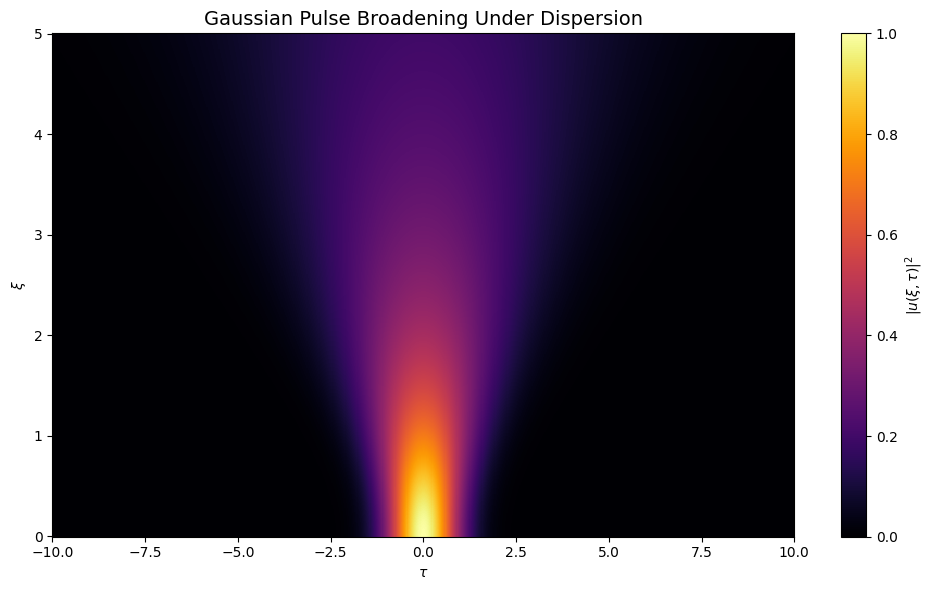

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
im = plot_propagation_map(
    ax, tau, xi_arr, u_hist,
    tau_lim=(-10, 10),
    cmap='inferno',
    title='Gaussian Pulse Broadening Under Dispersion',
)
ax.set_title('Gaussian Pulse Broadening Under Dispersion', fontsize=14)
fig.colorbar(im, ax=ax, label=r'$|u(\xi,\tau)|^2$')
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb01_propagation_map.png")
plt.show()

The propagation map shows the Gaussian pulse spreading symmetrically as it propagates.
The peak intensity decreases because the pulse energy is conserved while the width grows.

## Result 2: Pulse Width vs. Propagation Distance

We compute the RMS pulse width at each $\xi$ and compare against the analytical formula
$T(\xi) = T_0\sqrt{1 + \xi^2}$.

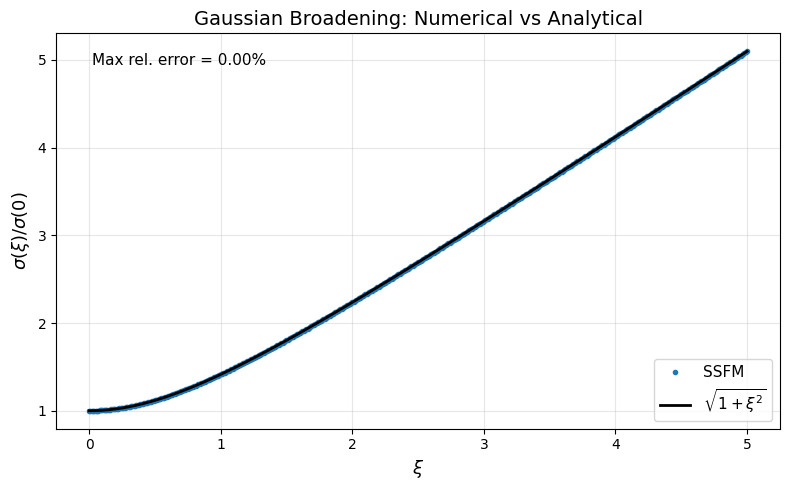

In [6]:
widths = np.array([rms_width(u, tau, dtau) for u in u_hist])
width_ratio = widths / widths[0]
width_exact = np.sqrt(1 + xi_arr**2)
max_broadening_err = np.max(np.abs(width_ratio - width_exact) / width_exact)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(xi_arr, width_ratio, 'o', ms=3, label='SSFM')
ax.plot(xi_arr, width_exact, 'k-', linewidth=2, label=r'$\sqrt{1+\xi^2}$')
ax.text(0.05, 0.92, f'Max rel. error = {max_broadening_err:.2%}',
        transform=ax.transAxes, fontsize=11)
ax.set_xlabel(r'$\xi$', fontsize=13)
ax.set_ylabel(r'$\sigma(\xi)/\sigma(0)$', fontsize=13)
ax.set_title('Gaussian Broadening: Numerical vs Analytical', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb01_width_vs_distance.png")
plt.show()
assert max_broadening_err < 0.02

### Sign-Sensitive Complex Field Validation

The width check alone cannot detect a dispersion-sign error. We compare the full complex
field against the exact analytical solution $u(\xi,\tau) = q^{-1/2} \exp(-\tau^2/(2q))$
where $q = 1 + is\xi$.

In [7]:
def gaussian_dispersion_exact(tau_grid, xi, s_val):
    q = 1 + 1j * s_val * xi
    return q**(-0.5) * np.exp(-tau_grid**2 / (2 * q))

u_exact = gaussian_dispersion_exact(tau, xi_arr[-1], s)
complex_gaussian_err = np.max(np.abs(u_hist[-1] - u_exact))
print(f"Complex Gaussian field error: {complex_gaussian_err:.2e}")
assert complex_gaussian_err < 1e-3

Complex Gaussian field error: 1.35e-08


## Result 3: Chirp Development

Dispersion creates a **phase profile** and a corresponding **frequency chirp** — the
instantaneous frequency varies across the pulse. We visualize the unwrapped phase
$\phi(\tau)$ and the instantaneous frequency $\omega_i(\tau) = -d\phi/d\tau$ at
different propagation distances. For the linear Gaussian solution,
$\omega_i(\tau,\xi) = -s\xi\tau/(1+\xi^2)$, so anomalous and normal dispersion
produce opposite chirp slopes.

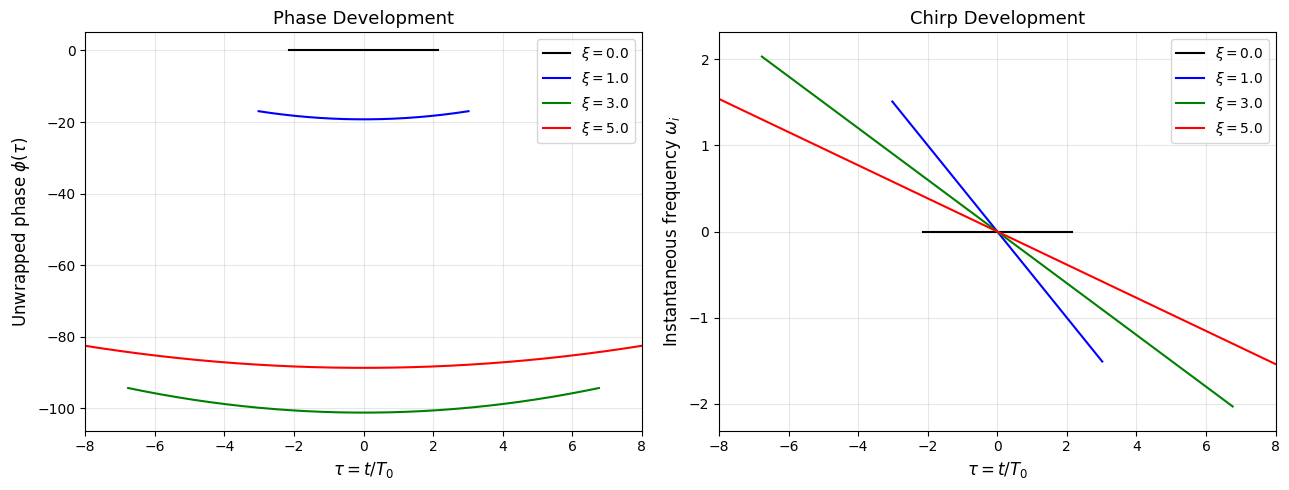

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

distances = [0, 1.0, 3.0, 5.0]
colors = ['black', 'blue', 'green', 'red']

for xi_val, color in zip(distances, colors):
    idx = np.argmin(np.abs(xi_arr - xi_val))
    u_at_xi = u_hist[idx]
    phase = np.unwrap(np.angle(u_at_xi))
    omega_inst = instantaneous_frequency(u_at_xi, dtau, intensity_floor=0.01)
    mask = np.isfinite(omega_inst)

    axes[0].plot(tau[mask], phase[mask], color=color, linewidth=1.5,
                 label=rf'$\xi = {xi_val:.1f}$')
    axes[1].plot(tau[mask], omega_inst[mask], color=color, linewidth=1.5,
                 label=rf'$\xi = {xi_val:.1f}$')

axes[0].set_ylabel(r'Unwrapped phase $\phi(\tau)$', fontsize=12)
axes[0].set_title('Phase Development', fontsize=13)
axes[1].set_ylabel(r'Instantaneous frequency $\omega_i$', fontsize=12)
axes[1].set_title('Chirp Development', fontsize=13)
for ax in axes:
    ax.set_xlabel(r'$\tau = t/T_0$', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-8, 8)
fig.tight_layout()
save_figure(fig, FIG_DIR / "nb01_chirp_development.png")
plt.show()

**Physical interpretation:**
- At $\xi = 0$: flat phase and no chirp ($\omega_i \approx$ constant)
- At $\xi > 0$: linear chirp develops — $\omega_i$ varies linearly with $\tau$
- For anomalous dispersion ($s = +1$): leading edge blue-shifted, trailing edge red-shifted
- The chirp grows with propagation distance — this is what causes the broadening

## Result 4: Anomalous vs. Normal Dispersion

Both anomalous ($s = +1$, $\beta_2 < 0$) and normal ($s = -1$, $\beta_2 > 0$) dispersion
cause broadening at the same rate. The sign-sensitive observable is the **chirp direction**:
- Anomalous: leading edge blue-shifted, trailing edge red-shifted
- Normal: leading edge red-shifted, trailing edge blue-shifted

This distinction becomes crucial when we add nonlinearity — solitons only exist in
anomalous dispersion.

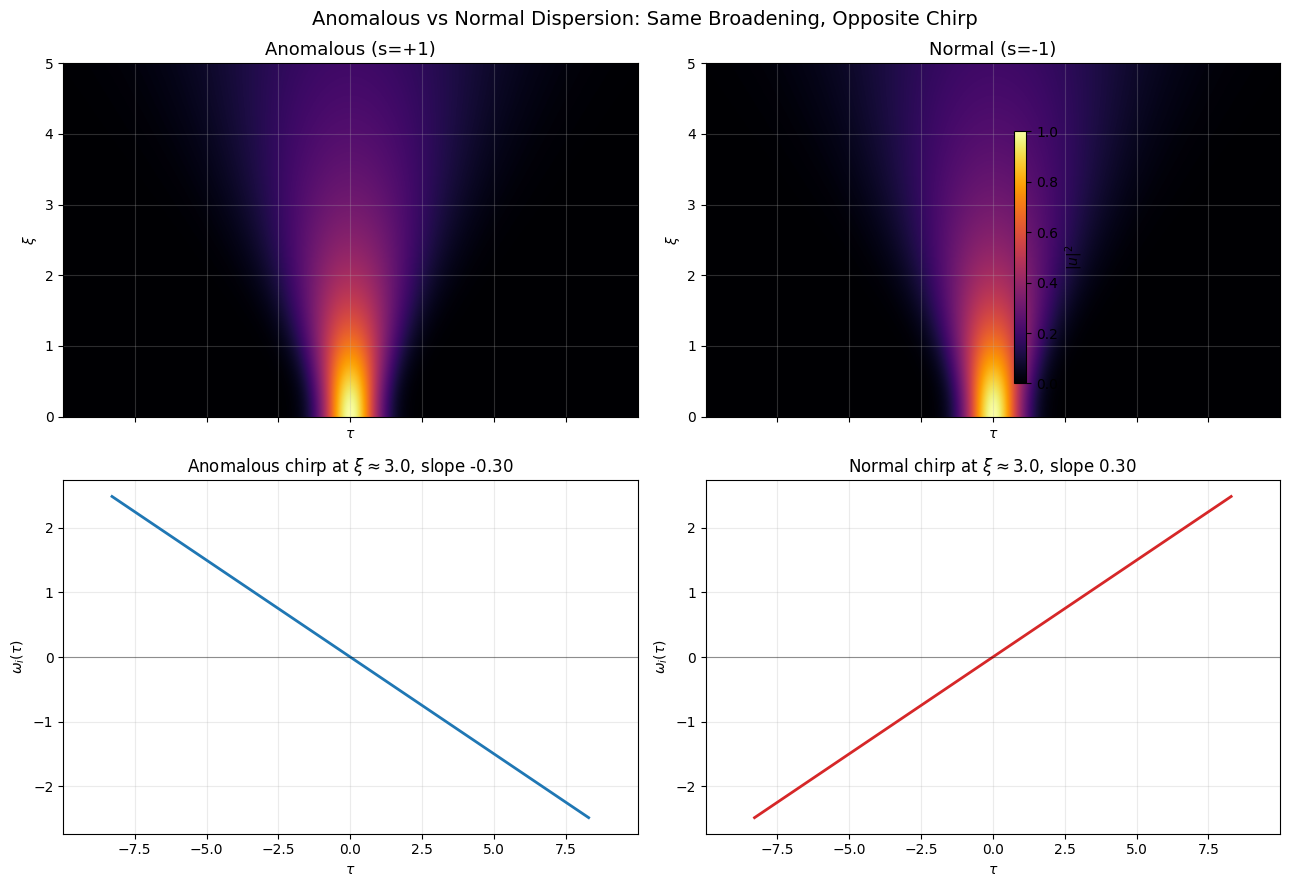

In [9]:
xi_arr_norm, u_hist_norm = ssfm_propagate(
    u0, tau, omega, xi_max=xi_max, N_z=N_z, s=-1, N_sq=0.0
)

target_xi = 3.0
idx_anom = np.argmin(np.abs(xi_arr - target_xi))
idx_norm = np.argmin(np.abs(xi_arr_norm - target_xi))

u_anom = u_hist[idx_anom]
u_norm = u_hist_norm[idx_norm]
chirp_anom = instantaneous_frequency(u_anom, dtau, intensity_floor=1e-3)
chirp_norm = instantaneous_frequency(u_norm, dtau, intensity_floor=1e-3)

mask_a = np.isfinite(chirp_anom)
mask_n = np.isfinite(chirp_norm)
slope_anom = np.polyfit(tau[mask_a], chirp_anom[mask_a], 1)[0]
slope_norm = np.polyfit(tau[mask_n], chirp_norm[mask_n], 1)[0]
assert slope_anom < 0 and slope_norm > 0

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex='col')
mask = (tau >= -10) & (tau <= 10)
for ax, hist, xi_grid, title in zip(
    axes[0],
    [u_hist, u_hist_norm],
    [xi_arr, xi_arr_norm],
    ['Anomalous (s=+1)', 'Normal (s=-1)'],
):
    im = ax.imshow(
        np.abs(hist[:, mask])**2, aspect='auto', origin='lower',
        extent=[tau[mask][0], tau[mask][-1], xi_grid[0], xi_grid[-1]],
        cmap='inferno',
    )
    ax.set_title(title, fontsize=13)
    ax.set_ylabel(r'$\xi$')

axes[1, 0].plot(tau[mask_a], chirp_anom[mask_a], color='tab:blue', lw=2)
axes[1, 0].axhline(0, color='black', lw=0.8, alpha=0.4)
axes[1, 0].set_title(
    rf'Anomalous chirp at $\xi \approx {xi_arr[idx_anom]:.1f}$, slope {slope_anom:.2f}',
    fontsize=12)
axes[1, 0].set_ylabel(r'$\omega_i(\tau)$')

axes[1, 1].plot(tau[mask_n], chirp_norm[mask_n], color='tab:red', lw=2)
axes[1, 1].axhline(0, color='black', lw=0.8, alpha=0.4)
axes[1, 1].set_title(
    rf'Normal chirp at $\xi \approx {xi_arr_norm[idx_norm]:.1f}$, slope {slope_norm:.2f}',
    fontsize=12)
axes[1, 1].set_ylabel(r'$\omega_i(\tau)$')

for ax in axes.ravel():
    ax.set_xlabel(r'$\tau$')
    ax.grid(True, alpha=0.25)

fig.colorbar(im, ax=axes[0], label=r'$|u|^2$', shrink=0.8)
fig.suptitle('Anomalous vs Normal Dispersion: Same Broadening, Opposite Chirp',
             fontsize=14)
save_figure(fig, FIG_DIR / "nb01_anomalous_vs_normal.png")
plt.show()